# Project 1 — Chest X-Ray Analysis

## Goal
Process and analyze chest X-ray scans using classical computer vision
techniques to highlight lung regions, detect structural boundaries, and isolate
areas of interest — simulating the preprocessing stage of a real medical AI
pipeline for thoracic radiology.

## Disease Description
The **NIH Chest X-Ray Dataset** contains scans labeled with 14 thoracic
diseases including Pneumonia, Pleural Effusion, Cardiomegaly, Atelectasis,
and Nodules among others. Chest X-ray is one of the most commonly performed
medical imaging procedures globally and accurate automated analysis of these
scans is a critical problem in clinical AI.

## Dataset
NIH Chest X-Ray Dataset
Source: kaggle.com/datasets/nih-chest-xrays/data
Total images: 112,120 chest X-rays from 30,805 unique patients
Labels: 14 disease classes + No Finding
Format: PNG 1024x1024

## Techniques Applied
- Grayscale conversion
- CLAHE contrast enhancement
- Binary thresholding
- Morphological operations (opening & closing)
- Canny edge detection
- Contour detection and drawing

## Expected Output
A side by side comparison showing the original scan, enhanced image,
detected edges, and contours drawn over the lung and structural regions.Sonnet 4.6Claude is 

## IMAGE 1 (0.jpg) - Lateral Chest X-Ray (Overexposed)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline 
import cv2

In [2]:
color_img = cv2.imread('DATA/0.jpg')

In [3]:
gray_img = cv2.imread('DATA/0.JPG',0)

In [4]:
## Contrast enhancement
im = cv2.equalizeHist(gray_img)

In [5]:
## Apply Thresholding

ret,thresh = cv2.threshold(im,127,255,cv2.THRESH_BINARY_INV)

In [6]:
## Detect Edges

blurred = cv2.GaussianBlur(thresh,(5,5),0)
edges = cv2.Canny(blurred, 20,80)


In [7]:
## Find and Draw Contours

copy = color_img.copy()

contours, hierachy = cv2.findContours(edges, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
cv2.drawContours(copy,contours,-1,(0,255,0),5)

array([[[  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

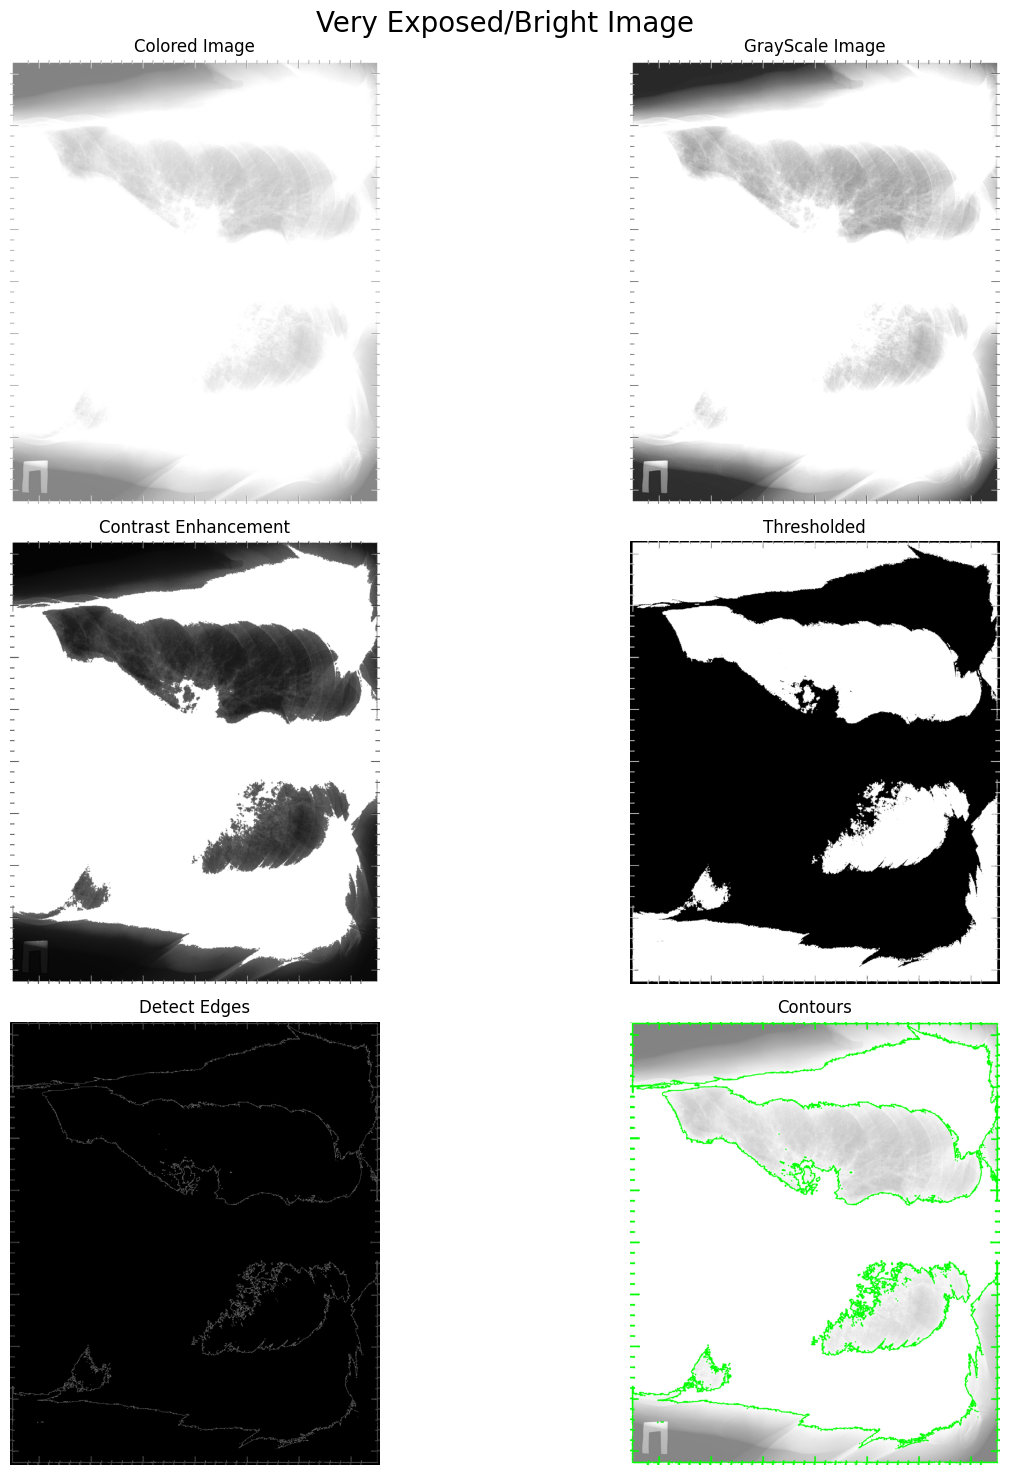

In [8]:
plt.figure(figsize=(15,15))

plt.subplot(321);plt.imshow(color_img);plt.title("Colored Image");plt.axis("off")
plt.subplot(322);plt.imshow(gray_img,cmap='gray');plt.title("GrayScale Image");plt.axis("off")
plt.subplot(323);plt.imshow(im,cmap='gray');plt.title("Contrast Enhancement");plt.axis("off")
plt.subplot(324);plt.imshow(thresh,cmap='gray');plt.title("Thresholded");plt.axis("off")
plt.subplot(325);plt.imshow(edges,cmap='gray');plt.title("Detect Edges");plt.axis("off")
plt.subplot(326);plt.imshow(copy,cmap='gray');plt.title("Contours");plt.axis("off")

plt.suptitle("Very Exposed/Bright Image", fontsize = 20)
plt.tight_layout()
plt.show()


## IMAGE 2 (1.jpg) - Clean Frontal Chest X-Ray

In [9]:
color_img = cv2.imread('Data/1.jpg')
color_img = cv2.cvtColor(color_img,cv2.COLOR_BGR2RGB)

In [10]:
gray_img = cv2.imread('Data/1.jpg', 0)

In [11]:
## Apply Thresholding

ret, thresh = cv2.threshold(gray_img, 127, 255, cv2.THRESH_BINARY_INV)

In [12]:
## Morphological Operator

kernel = np.ones((5,5),np.uint8)

cleaned = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel)

In [13]:
## Find Contours of both lungs
copy = color_img.copy()

contours, hierachy = cv2.findContours(cleaned, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
#cv2.drawContours(copy,contours,-1,(255,0,0),5)
# bounding = sorted(contours,key=cv2.contourArea , reverse=True)[:2]
contours = sorted(contours,key=cv2.contourArea , reverse=True)
largest_two = contours[:2]

for cnt in largest_two:
    x,y,w,h = cv2.boundingRect(cnt)
    cv2.rectangle(copy, (x,y), (x+w, y+h), (255,0,0),2)
    area = cv2.contourArea(cnt)
    cv2.putText(copy,f'Area:{int(area)}', (x, y-10),cv2.FONT_HERSHEY_SIMPLEX,0.5,(0,255,0),1)
    

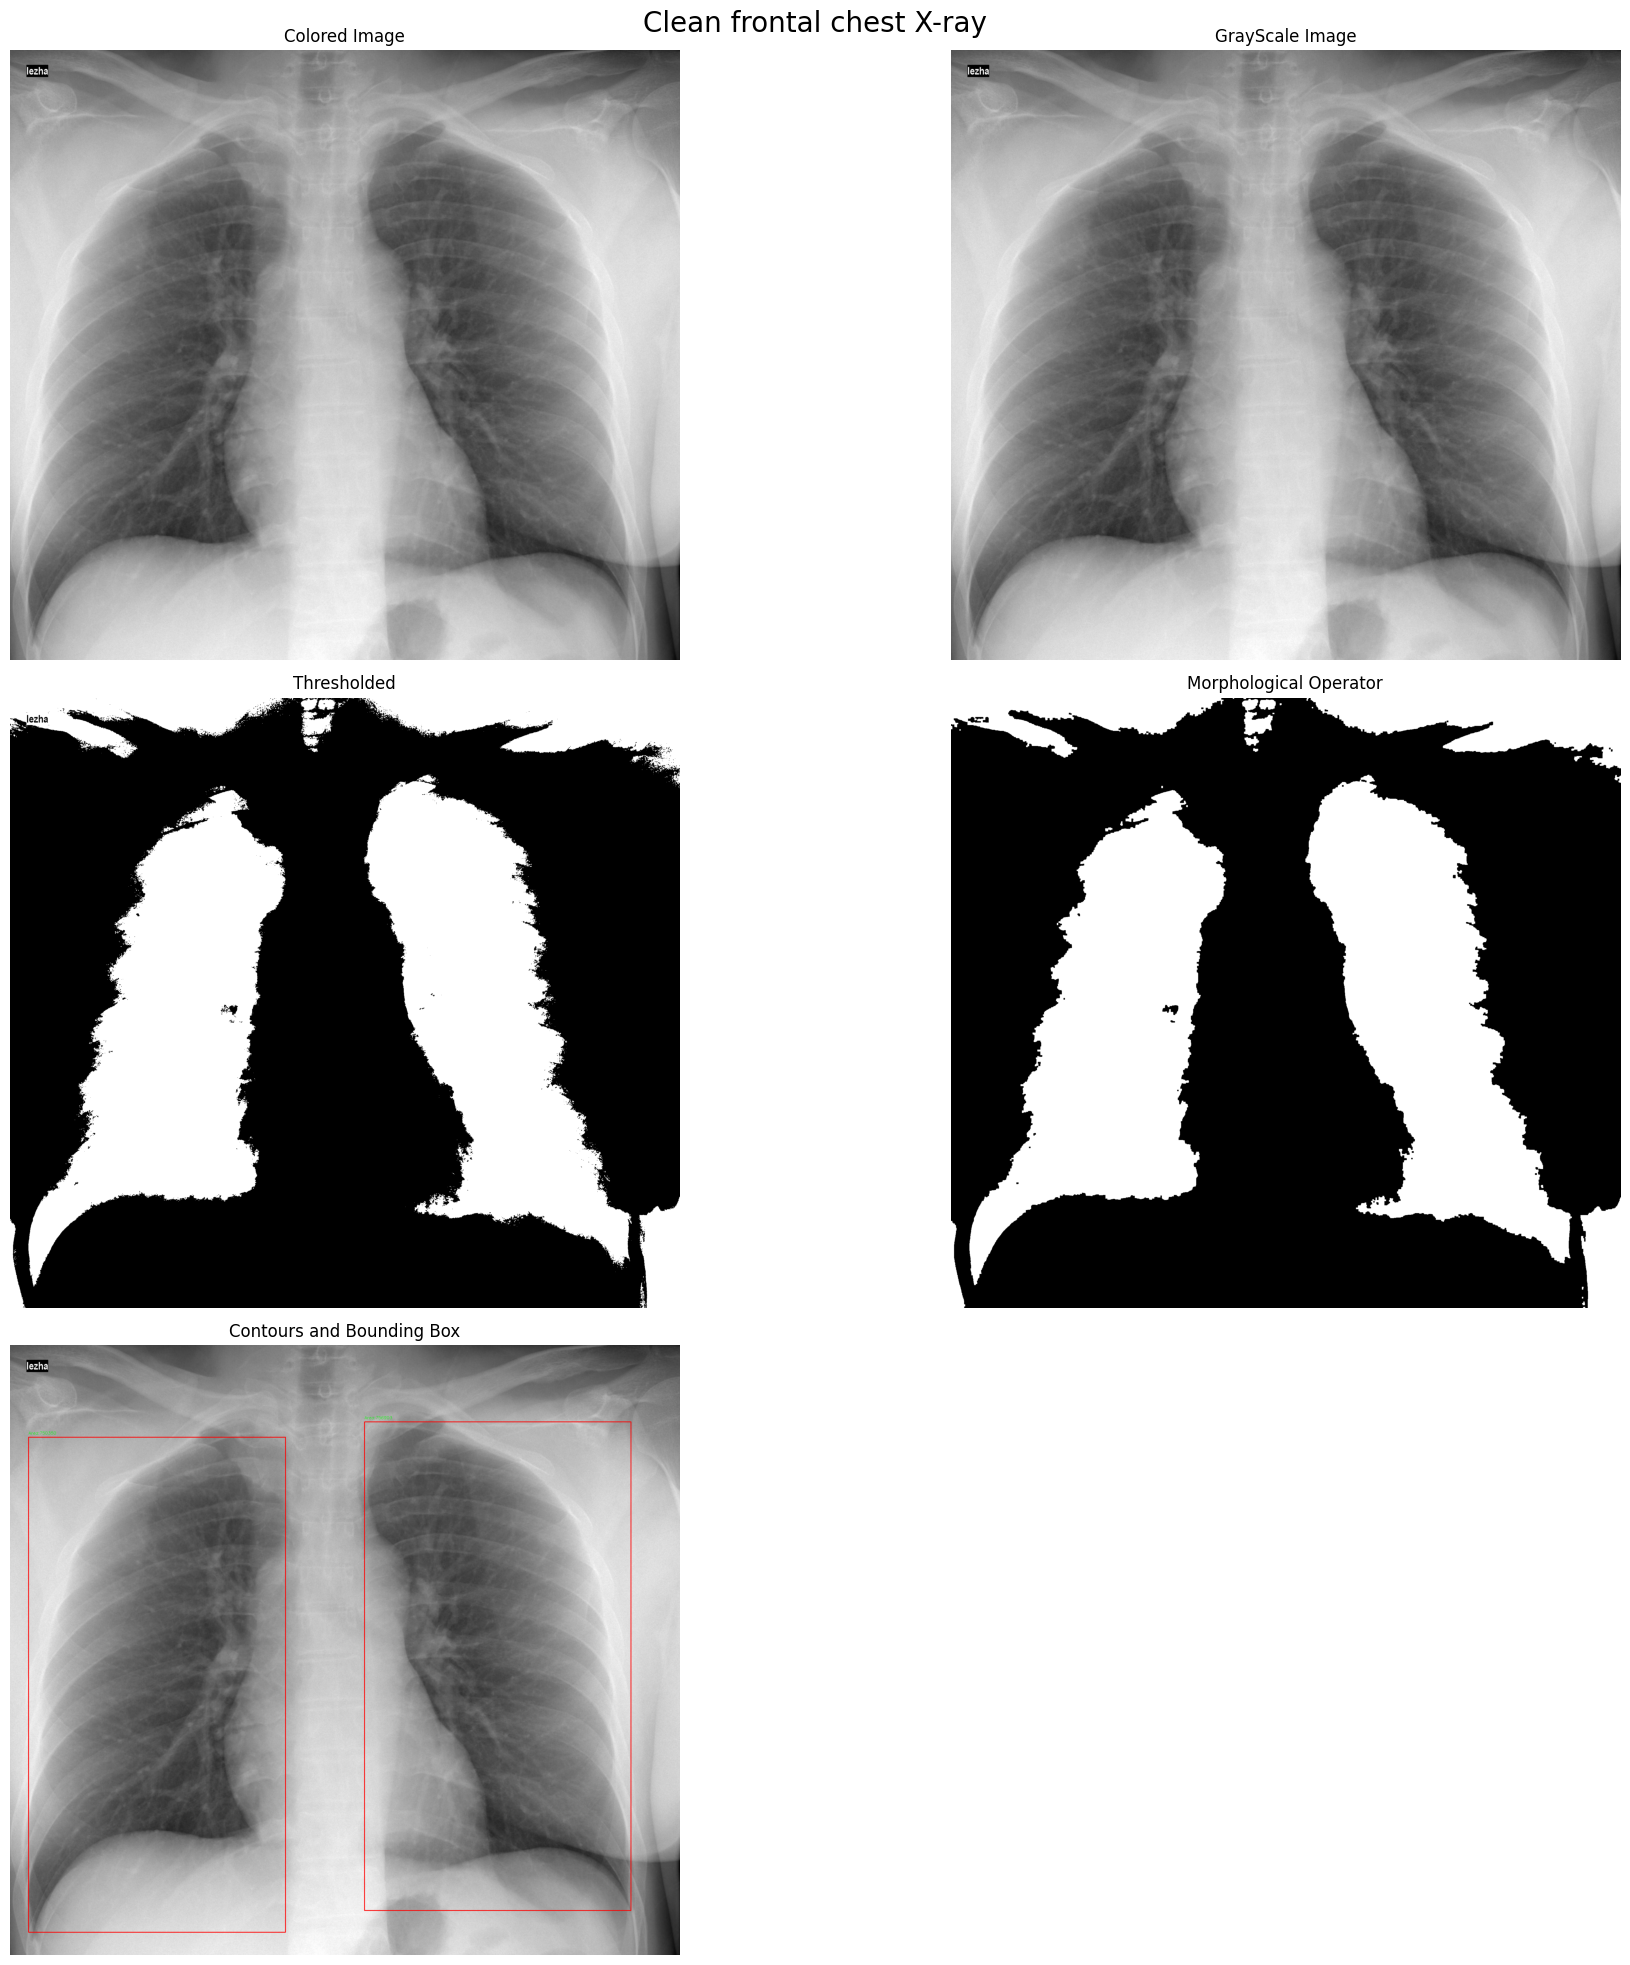

Lung 1 area: 756903 pixels
Lung 2 area: 750350 pixels


In [14]:
plt.figure(figsize=(20,20))

plt.subplot(321);plt.imshow(color_img);plt.title("Colored Image");plt.axis("off")
plt.subplot(322);plt.imshow(gray_img,cmap='gray');plt.title("GrayScale Image");plt.axis("off")
plt.subplot(323);plt.imshow(thresh,cmap='gray');plt.title("Thresholded");plt.axis("off")
plt.subplot(324);plt.imshow(cleaned,cmap='gray');plt.title("Morphological Operator");plt.axis("off")
plt.subplot(325);plt.imshow(copy,cmap='gray');plt.title("Contours and Bounding Box");plt.axis("off")

plt.suptitle("Clean frontal chest X-ray", fontsize = 20)
plt.tight_layout()
plt.show()

for i, cnt in enumerate (largest_two):
    print(f"Lung {i+1} area: {int(cv2.contourArea(cnt))} pixels")


## IMAGE 3 (2.jpg) - Cardiomegaly (Enlarged Heart)

In [2]:
color_img = cv2.imread('Data/2.jpg')


In [3]:
gray_img = cv2.imread('Data/2.jpg',0)

In [4]:
## Apply Thresholding

ret,thresh = cv2.threshold(gray_img,0,255,cv2.THRESH_BINARY)

In [5]:
## Morphological Operator

kernel = np.ones((7,7),np.uint8)
cleaned = cv2.morphologyEx(thresh,cv2.MORPH_OPEN,kernel)
cleaned = cv2.morphologyEx(cleaned,cv2.MORPH_CLOSE,kernel)

In [7]:

img3 = cv2.imread('Data/2.jpg')
color_img3 = cv2.cvtColor(img3, cv2.COLOR_BGR2RGB)
gray3 = cv2.cvtColor(img3, cv2.COLOR_BGR2GRAY)

# Contrast enhancement
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
enhanced3 = clahe.apply(gray3)

# Threshold using Otsu
_, thresh3 = cv2.threshold(enhanced3, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Clean up
kernel = np.ones((7,7), np.uint8)
cleaned3 = cv2.morphologyEx(thresh3, cv2.MORPH_CLOSE, kernel)
cleaned3 = cv2.morphologyEx(cleaned3, cv2.MORPH_OPEN, kernel)

# Find contours
contours3, _ = cv2.findContours(cleaned3, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contours3_sorted = sorted(contours3, key=cv2.contourArea, reverse=True)

# Filter to heart sized contours only
filtered = []
for cnt in contours3_sorted:
    area = cv2.contourArea(cnt)
    if area > 50000 and area < 500000:
        filtered.append(cnt)

heart_contour = filtered[0]

# Draw bounding box on copy
copy3 = img3.copy()
x, y, w, h = cv2.boundingRect(heart_contour)
cv2.rectangle(copy3, (x,y), (x+w, y+h), (0,0,255), 3)
cv2.putText(copy3, 'Heart Region', (x, y-10),
            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,0,255), 2)

# Cardiothoracic ratio
chest_width = gray3.shape[1]
heart_width = w
ct_ratio = heart_width / chest_width

# Display
fig, axes = plt.subplots(1, 3, figsize=(18,6))

axes[0].imshow(color_img3)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(cleaned3, cmap='gray')
axes[1].set_title('Thresholded')
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(copy3, cv2.COLOR_BGR2RGB))
axes[2].set_title('Heart Region Detected')
axes[2].axis('off')

plt.suptitle('Image 3 - Cardiomegaly Detection', fontsize=14)
plt.tight_layout()
plt.show()

# Print results
print(f"Heart width:  {heart_width}px")
print(f"Chest width:  {chest_width}px")
print(f"CT Ratio:     {ct_ratio:.2f}")

if ct_ratio > 0.5:
    print("WARNING: CT Ratio > 0.5 — Possible Cardiomegaly")
else:
    print("CT Ratio normal")

IndexError: list index out of range

## IMAGE 4(3.jpg) -- Lateral Left Chest

## IMAGE 5 (4.jpg) -- Clean Frontal Chest 

In [2]:
color_img = cv2.imread('Data/4.jpg')

In [3]:
gray_img = cv2.imread('Data/4.jpg',0)

In [4]:
ret,thresh = cv2.threshold(gray_img,127,255,cv2.THRESH_BINARY_INV)

In [30]:
## Use Morphological Operators to clean Image

kernel = np.ones((5,5),np.uint8)

cleaned = cv2.morphologyEx(thresh,cv2.MORPH_OPEN,kernel)
cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE,kernel)

Left Lung Area: 1184200
Right Lung Area: 1255438
Right Lung is larger by 5.7%


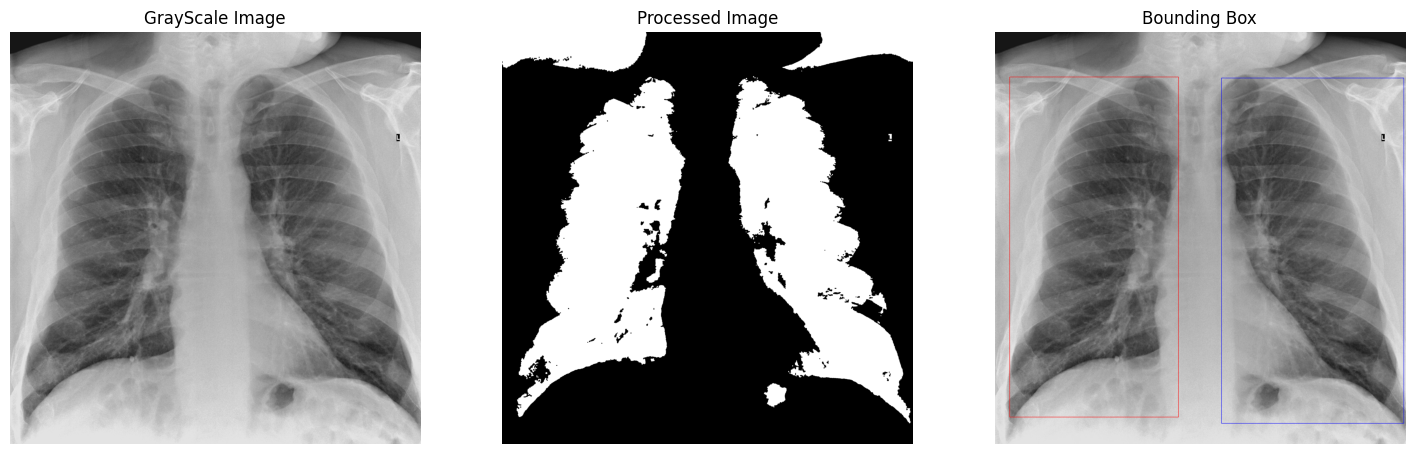

In [37]:
## Find Contours of both lungs
copy5 = color_img.copy()

contours,hierachy = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contours_sorted = sorted(contours,key=cv2.contourArea,reverse=True)

right_lung = contours_sorted[0]
left_lung = contours_sorted[1]

x,y,w,h = cv2.boundingRect(right_lung)
cv2.rectangle(copy5,(x,y),(x+w,y+h),(255,0,0),2)
right_area = cv2.contourArea(right_lung)

x,y,w,h = cv2.boundingRect(left_lung)
cv2.rectangle(copy5,(x,y),(x+w,y+h),(0,0,255),2)
left_area = cv2.contourArea(left_lung)

fig,axes = plt.subplots(1,3,figsize=(18,6))

axes[0].imshow(gray_img,cmap='gray')
axes[0].set_title("GrayScale Image")
axes[0].axis('off')

axes[1].imshow(cleaned,cmap='gray')
axes[1].set_title("Processed Image")
axes[1].axis('off')

axes[2].imshow(copy5,cmap='gray')
axes[2].set_title("Bounding Box")
axes[2].axis('off')

diff = abs(left_area - right_area)
pct = (diff/max(left_area, right_area)) * 100

if left_area > right_area:
    larger = "Left Lung"
else:
    larger = "Right Lung"

print(f"Left Lung Area: {int(left_area)}")
print(f"Right Lung Area: {int(right_area)}")
print(f"{larger} is larger by {pct:.1f}%")

## IMAGE 6(5.jpg) -- Lateral Chest

In [39]:
color_img = cv2.imread('Data/5.jpg')

In [40]:
gray_img = cv2.imread('Data/5.jpg',0)

In [41]:
clahe = cv2.createCLAHE(clipLimit=2.0,tileGridSize=(8,8))
enhanced = clahe.apply(gray_img)

In [42]:
ret,thresh = cv2.threshold(enhanced, 127, 225, cv2.THRESH_BINARY)

In [43]:
kernel = np.ones((5,5),np.uint8)

cleaned = cv2.morphologyEx(thresh,cv2.MORPH_OPEN,kernel)
cleaned = cv2.morphologyEx(cleaned,cv2.MORPH_CLOSE,kernel)

In [44]:
blurred = cv2.GaussianBlur(cleaned,(5,5),0)
edges = cv2.Canny(blurred, 20,80)

In [55]:
copy6 = color_img.copy()

contours, hierachy = cv2.findContours(edges, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
cv2.drawContours(copy6,contours,-1,(0,255,0),5)



array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [227, 227, 227],
        [255, 255, 255],
        [231, 231, 231]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [243, 243, 243],
        [123, 123, 123]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [248, 248, 248],
        [115, 115, 115],
        [255, 255, 255]]

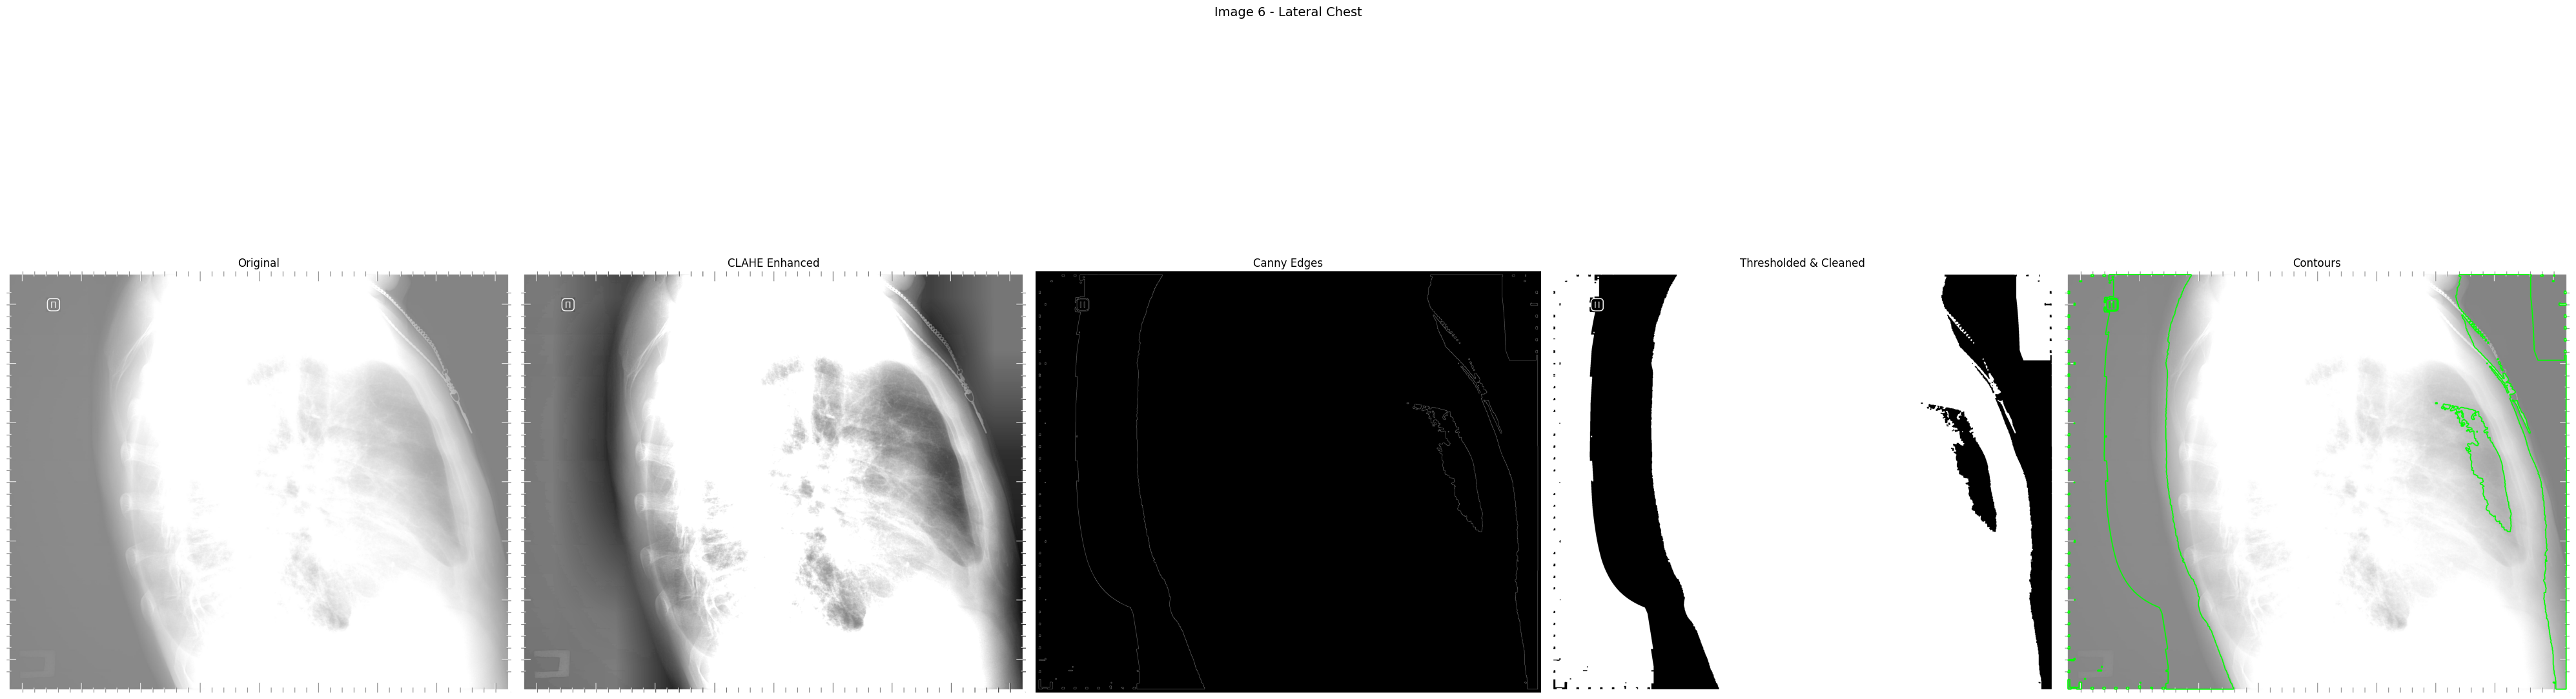

Total structures detected:      192


In [62]:

# Display all stages
fig, axes = plt.subplots(1,5,figsize=(40,15))

axes[0].imshow(color_img)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(enhanced, cmap='gray')
axes[1].set_title('CLAHE Enhanced')
axes[1].axis('off')

axes[2].imshow(edges, cmap='gray')
axes[2].set_title('Canny Edges')
axes[2].axis('off')

axes[3].imshow(cleaned, cmap='gray')
axes[3].set_title('Thresholded & Cleaned')
axes[3].axis('off')

axes[4].imshow(cv2.cvtColor(copy6, cv2.COLOR_BGR2RGB))
axes[4].set_title('Contours')
axes[4].axis('off')

plt.suptitle('Image 6 - Lateral Chest', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Total structures detected:      {len(contours)}")